# Multiple Linear Regression
## Housing Case Study

#### Problem Statement:

Consider a real estate company that has a dataset containing the prices of properties in the Delhi region. It wishes to use the data to optimise the sale prices of the properties based on important factors such as area, bedrooms, parking, etc.

Essentially, the company wants —


- To identify the variables affecting house prices, e.g. area, number of rooms, bathrooms, etc.

- To create a linear model that quantitatively relates house prices with variables such as number of rooms, area, number of bathrooms, etc.

- To know the accuracy of the model, i.e. how well these variables can predict house prices.

**So interpretation is important!**
The steps we will follow in this exercise are as follows:
1. Reading, understanding and visualising the data
2. Preparing the data for modelling (train-test split, rescaling etc.)
3. Training the model
4. Residual analysis
5. Predictions and evaluation on the test set

## Step 1: Reading and Understanding the Data

Let us first import NumPy and Pandas and read the housing dataset

In [1]:
import warnings

warnings.filterwarnings("ignore")

### Importing necessary libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df_dw = df.describe()


# Normalize column area with min=0 and max=1
def min_max_scale(column, min_val, max_val):
    if type(column) == "int64":
        return (column - column.min()) / (column.max() - column.min()) * (
            max_val - min_val
        ) + min_val
    else:
        return column


df_dw = min_max_scale(df_dw, min_val=0, max_val=1)
df_dw

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Step 2: Visualising the Data

Let's now spend some time doing what is arguably the most important step - **understanding the data**.
- If there is some obvious multicollinearity going on, this is the first place to catch it
- Here's where you'll also identify if some predictors directly have a strong association with the outcome variable

We'll visualise our data using `matplotlib` and `seaborn`.

In [9]:
df_dw

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [11]:
# 100*df.isna().mean()

<Figure size 900x700 with 0 Axes>

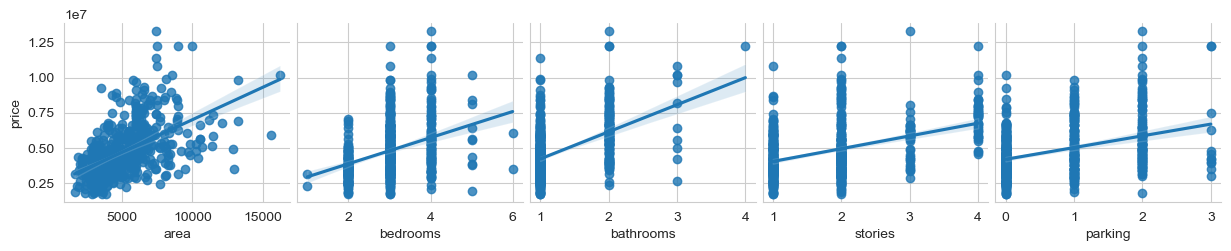

In [12]:
plt.figure(figsize=(9, 7))
sns.pairplot(
    df,
    x_vars=["area", "bedrooms", "bathrooms", "stories", "parking"],
    y_vars="price",
    kind="reg",
)
plt.show()

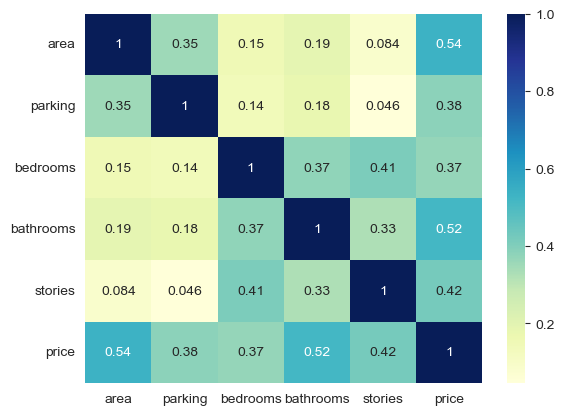

In [13]:
sns.heatmap(
    df[["area", "parking", "bedrooms", "bathrooms", "stories", "price"]].corr(),
    cmap="YlGnBu",
    annot=True,
)
plt.show()

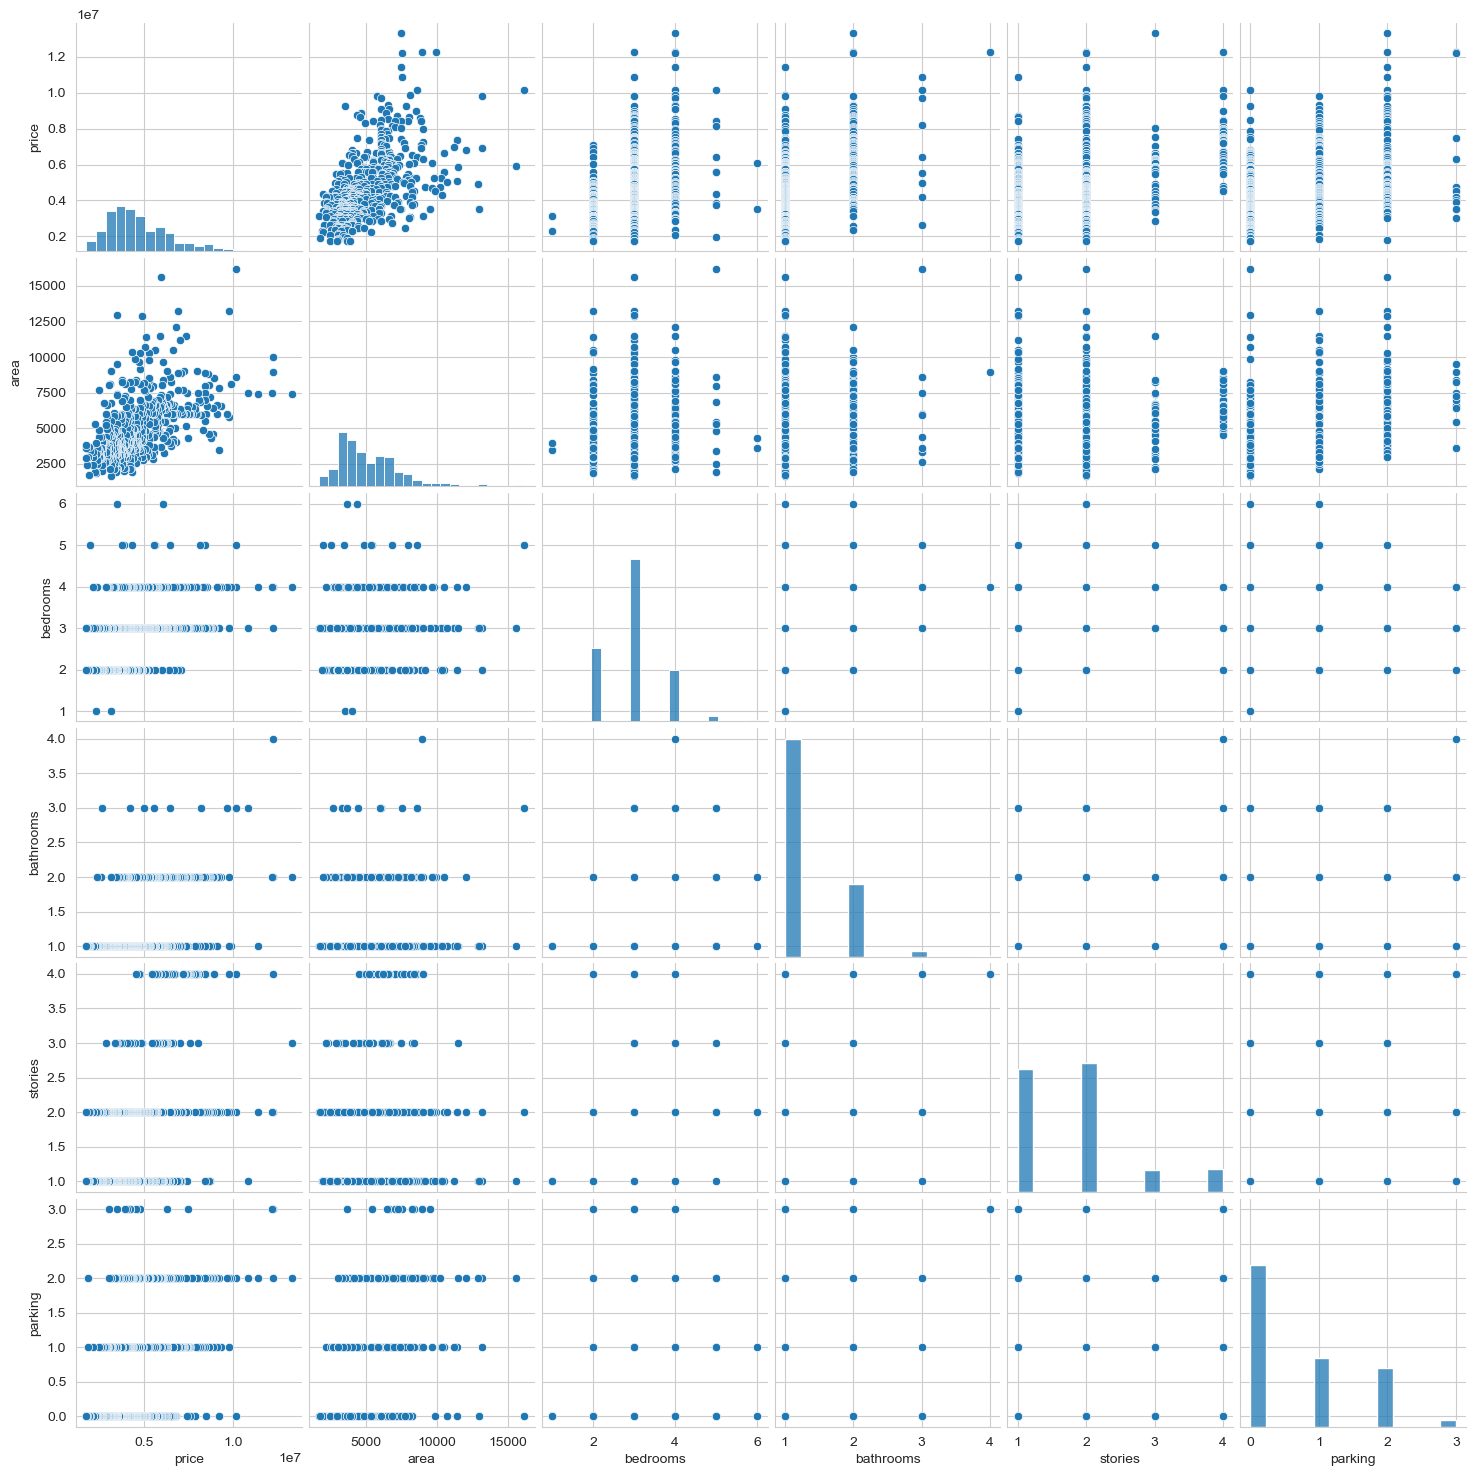

In [14]:
# visualising the numeric variables
sns.pairplot(df)
plt.show()

In [15]:
# visualising the categorical variables
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [16]:
df["mainroad"].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

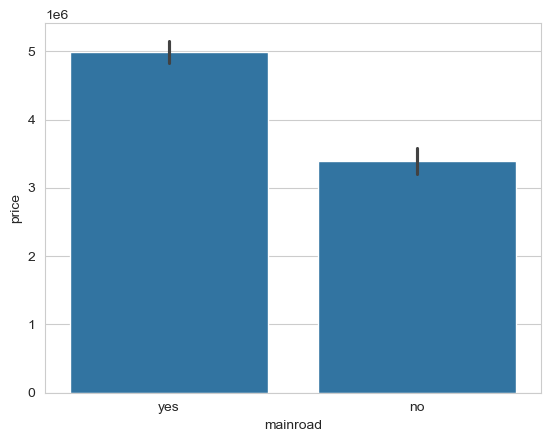

In [17]:
# fig,ax = plt.subplots(2,1,figsize=(12,7))
sns.barplot(df, x="mainroad", y="price")
plt.show()

In [18]:
df[df["mainroad"] == "yes"]["price"].max()

13300000

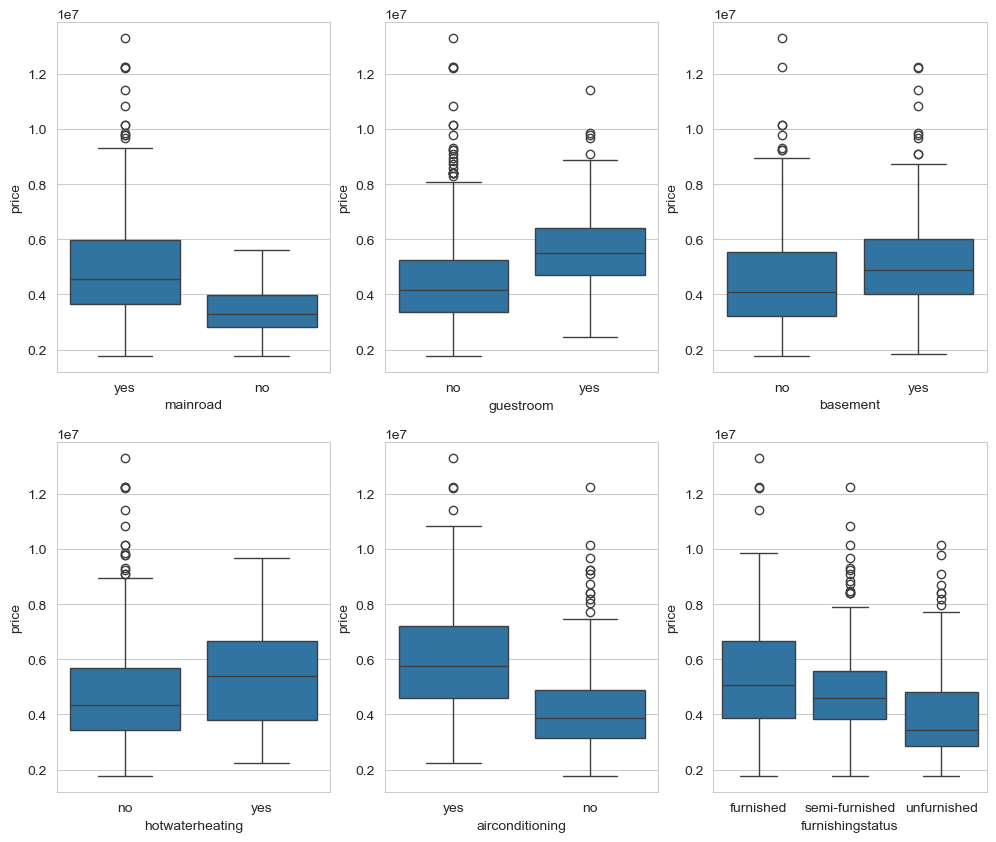

In [19]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 3, 1)
sns.boxplot(df, x="mainroad", y="price")
plt.subplot(2, 3, 2)
sns.boxplot(df, x="guestroom", y="price")
plt.subplot(2, 3, 3)
sns.boxplot(df, x="basement", y="price")
plt.subplot(2, 3, 4)
sns.boxplot(df, x="hotwaterheating", y="price")
plt.subplot(2, 3, 5)
sns.boxplot(df, x="airconditioning", y="price")
plt.subplot(2, 3, 6)
sns.boxplot(df, x="furnishingstatus", y="price")
plt.show()

In [20]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


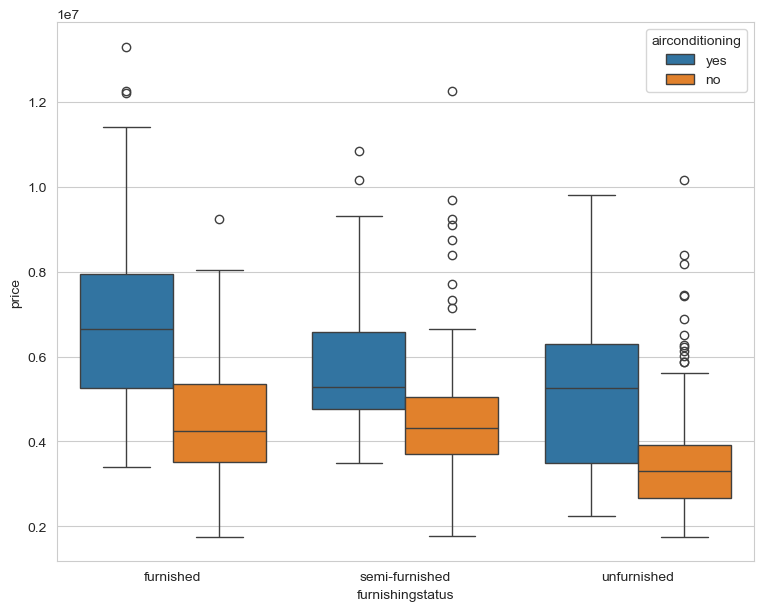

In [21]:
plt.figure(figsize=(9, 7))

sns.boxplot(df, x="furnishingstatus", y="price", hue="airconditioning")
plt.show()

### Data Preparation

### Encoding
    - Converting binary categorical variables to 1s and 0s
    - Creating dummy variables for other categorical variables

In [22]:
# yes/no variables
variable_names = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]
df[variable_names].head()
df[variable_names] = df[variable_names].map(lambda x: 1 if x == "yes" else 0)

In [23]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,semi-furnished
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,semi-furnished
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,unfurnished
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,furnished
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,unfurnished


In [24]:
# Creating hyperparameter for furnishing status
# Yeah ok no idea how to do in practice yet
# trying..
df1 = df.copy()
df1["unfurnished"] = df1[~(df1["furnishingstatus"] == "furnished")]["furnishingstatus"]

In [25]:
df1["furnished"] = df1[(df1["furnishingstatus"] == "furnished")]["furnishingstatus"]

In [26]:
df1.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,unfurnished,furnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,NaN,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,NaN,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,semi-furnished,NaN
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,NaN,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,NaN,furnished
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,semi-furnished,semi-furnished,NaN
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,semi-furnished,semi-furnished,NaN
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,unfurnished,unfurnished,NaN
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,furnished,NaN,furnished
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,unfurnished,unfurnished,NaN


In [27]:
df1["unfurnished"] = df1["unfurnished"].map(lambda x: 1 if x == "unfurnished" else 0)

In [28]:
df1["furnished"] = df1["furnished"].map(lambda x: 1 if x == "furnished" else 0)

In [29]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,unfurnished,furnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,0,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,0,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished,1,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished,0,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished,1,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished,0,1


In [30]:
## Using built in code
status = pd.get_dummies(df1["furnishingstatus"], dtype=int)
status = status[["furnished", "unfurnished"]]

In [31]:
housing = pd.concat([df, status], axis=1)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,1,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,1,0


In [32]:
housing.drop("furnishingstatus", axis=1, inplace=True)

In [33]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0


In [34]:
df1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,unfurnished,furnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,0,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,0,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished,1,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished,0,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished,1,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished,0,1


In [35]:
df1.drop("furnishingstatus", axis=1, inplace=True)

In [36]:
housing = df1.copy()

In [37]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,furnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,1


## Step3 Splitting into training and testing data

In [38]:
df_train, df_test = train_test_split(housing, train_size=0.7, random_state=100)

In [1]:
df_train.shape

NameError: name 'df_train' is not defined

In [ ]:
df_test.shape

In [ ]:
df_train.head()
y_train = df_train["price"]
X_train = df_train.drop("price", axis=1)

### Rescaling the Features
As you saw in the demonstration for Simple Linear Regression, scaling doesn't impact your model. Here we can see that except for area, all the columns have small integer values. So it is extremely important to rescale the variables so that they have a comparable scale. If we don't have comparable scales, then some of the coefficients as obtained by fitting the regression model might be very large or very small as compared to the other coefficients. This might become very annoying at the time of model evaluation. So it is advised to use standardization or normalization so that the units of the coefficients obtained are all on the same scale. As you know, there are two common ways of rescaling;
1. Min-Max scaling
2. Standardisation (mean-0, sigma-1)
This time, we will use MinMax scaling.

In [ ]:
y_test = df_test["price"]
X_test = df_test.drop("price", axis=1)

#### Normalisation

In [ ]:
temp = (X_train - X_train.min()) / (X_train.max() - X_train.min())

In [ ]:
temp.describe()

#### Standardisation


In [ ]:
temp1 = (X_train - X_train.mean()) / X_train.std()

In [ ]:
temp1.describe()

#### Using sklearn

In [47]:
# Create an object of minmaxscaler
scaler = MinMaxScaler()


# fit to numeric data
def numeric_vars(df):
    columns = []
    for col in df.columns.tolist():
        if df[col].dtype == "int64":
            columns.append(col)
    return columns


num_vars = ["area", "bedrooms", "bathrooms", "price", "stories", "parking", "price"]
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

In [48]:
df_train.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,furnished
359,0.169697,0.155227,0.4,0.0,0.000000,1,0,0,0,0,0.333333,0,1,0
19,0.615152,0.403379,0.4,0.5,0.333333,1,0,0,0,1,0.333333,1,0,0
159,0.321212,0.115628,0.4,0.5,0.000000,1,1,1,0,1,0.000000,0,0,1
35,0.548133,0.454417,0.4,0.5,1.000000,1,0,0,0,1,0.666667,0,0,1
28,0.575758,0.538015,0.8,0.5,0.333333,1,0,1,1,0,0.666667,0,1,0
267,0.229697,0.271383,0.4,0.0,0.333333,1,0,0,0,0,0.333333,0,0,0
263,0.230303,0.187610,0.4,0.0,0.333333,0,0,0,0,0,0.000000,0,0,0
433,0.133333,0.144667,0.6,0.0,0.333333,0,0,0,0,0,0.333333,0,0,0
217,0.266667,0.442274,0.4,0.0,0.333333,1,0,0,0,1,0.666667,1,0,1
154,0.327273,0.159627,0.4,0.5,0.333333,1,0,0,0,0,0.666667,0,0,0


In [49]:
df_train[num_vars].describe()

,area,bedrooms,bathrooms,price,stories,parking,price
count,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000
mean,0.288710,0.386352,0.136483,0.260333,0.268591,0.242345,0.260333
std,0.181420,0.147336,0.237325,0.157607,0.295001,0.285933,0.157607
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.155227,0.200000,0.000000,0.151515,0.000000,0.000000,0.151515
50%,0.234424,0.400000,0.000000,0.221212,0.333333,0.000000,0.221212
75%,0.398099,0.400000,0.500000,0.345455,0.333333,0.333333,0.345455
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Step 3: Training the model using Statslearn

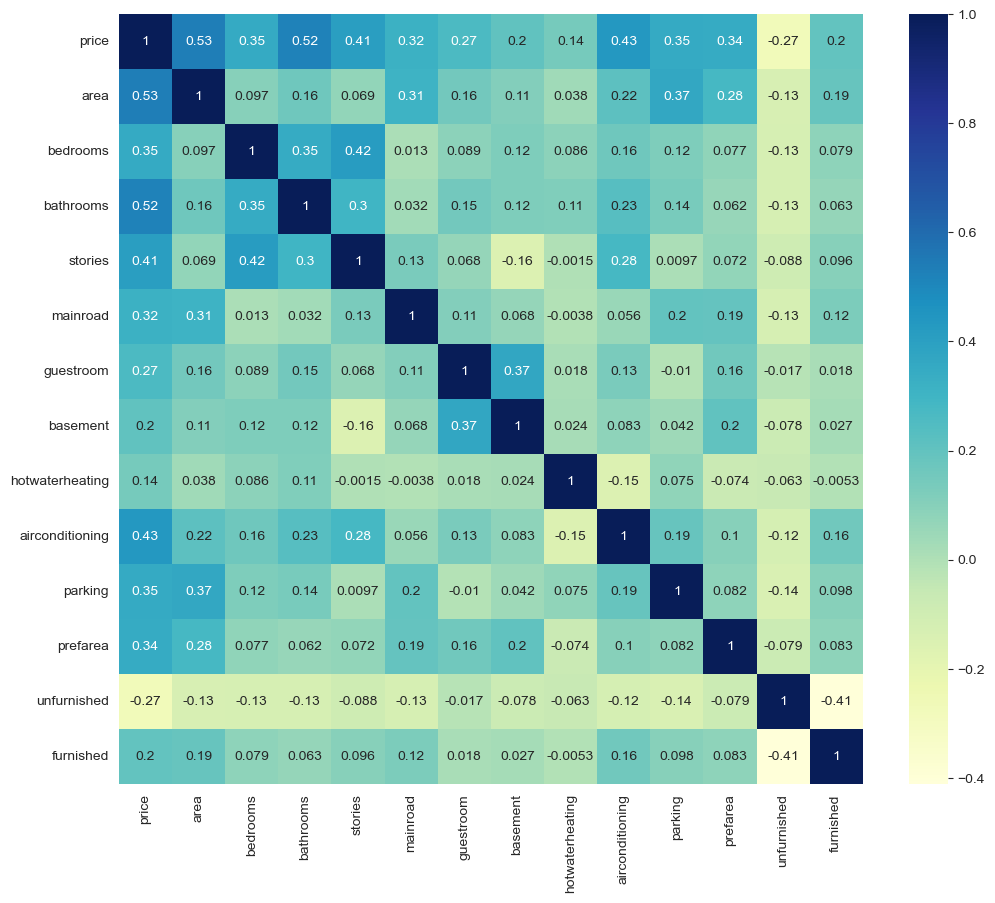

In [50]:
# heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu")  # YlGnBu
plt.show()

In [51]:
# Building models by taking 1 variable at a time
df_x = df_train.copy()
X_train, y_train = df_x, df_x.pop("price")  # Nice

- statical signifance of variables
- if variables are highly correlated, check VIF

In [52]:
# adding constant
X_train_sm = sm.add_constant(X_train["area"])
# training the model
linear_stats = sm.OLS(y_train, X_train_sm)
# fit
lr_model = linear_stats.fit()
# params
lr_model.params

const    0.126894
area     0.462192
dtype: float64

In [53]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     149.6
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           3.15e-29
Time:                        05:36:21   Log-Likelihood:                 227.23
No. Observations:                 381   AIC:                            -450.5
Df Residuals:                     379   BIC:                            -442.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1269      0.013      9.853      0.000       0.102       0.152
area           0.4622      0.038     12.232      0.000       0.388       0.536
==============================================================================
Omnibus:                       67.313   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              143.063
Skew:                           0.925   Prob(JB):                     8.59e-32
Kurtosis:                       5.365   Cond. No.                         5.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
with open("housing_summary.txt", "w") as f:
    f.write(str(lr_model.summary()))

In [55]:
# adding bathrooms predictor to the model
X_train_sm = sm.add_constant(X_train[["area", "bathrooms"]])
# training the model
linear_stats = sm.OLS(y_train, X_train_sm)
# fit
lr_model = linear_stats.fit()
# params
lr_model.params

const        0.104589
area         0.398396
bathrooms    0.298374
dtype: float64

In [56]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     174.1
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           2.51e-54
Time:                        05:36:21   Log-Likelihood:                 288.24
No. Observations:                 381   AIC:                            -570.5
Df Residuals:                     378   BIC:                            -558.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1046      0.011      9.384      0.000       0.083       0.127
area           0.3984      0.033     12.192      0.000       0.334       0.463
bathrooms      0.2984      0.025     11.945      0.000       0.249       0.347
==============================================================================
Omnibus:                       62.839   Durbin-Watson:                   2.157
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              168.790
Skew:                           0.784   Prob(JB):                     2.23e-37
Kurtosis:                       5.859   Cond. No.                         6.17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [57]:
# adding bedrooms predictor to the model
X_train_sm = sm.add_constant(X_train[["area", "bathrooms", "bedrooms"]])
# training the model
linear_stats = sm.OLS(y_train, X_train_sm)
# fit
lr_model = linear_stats.fit()
# summary
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     128.2
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           3.12e-57
Time:                        05:36:21   Log-Likelihood:                 297.76
No. Observations:                 381   AIC:                            -587.5
Df Residuals:                     377   BIC:                            -571.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0414      0.018      2.292      0.022       0.006       0.077
area           0.3922      0.032     12.279      0.000       0.329       0.455
bathrooms      0.2600      0.026     10.033      0.000       0.209       0.311
bedrooms       0.1819      0.041      4.396      0.000       0.101       0.263
==============================================================================
Omnibus:                       50.037   Durbin-Watson:                   2.136
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              124.806
Skew:                           0.648   Prob(JB):                     7.92e-28
Kurtosis:                       5.487   Cond. No.                         8.87
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [58]:
X_train_sm = sm.add_constant(
    X_train[["area", "bathrooms", "bedrooms", "airconditioning", "stories"]]
)
# training the model
linear_stats = sm.OLS(y_train, X_train_sm)
# fit
lr_model = linear_stats.fit()
# summary
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     106.2
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           1.30e-69
Time:                        05:36:21   Log-Likelihood:                 331.89
No. Observations:                 381   AIC:                            -651.8
Df Residuals:                     375   BIC:                            -628.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0443      0.017      2.672      0.008       0.012       0.077
area                0.3595      0.030     12.064      0.000       0.301       0.418
bathrooms           0.2155      0.024      8.860      0.000       0.168       0.263
bedrooms            0.0888      0.041      2.191      0.029       0.009       0.169
airconditioning     0.0695      0.012      5.668      0.000       0.045       0.094
stories             0.1034      0.020      5.084      0.000       0.063       0.143
==============================================================================
Omnibus:                       73.229   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              202.153
Skew:                           0.902   Prob(JB):                     1.27e-44
Kurtosis:                       6.079   Cond. No.                         10.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Adding more variables after bathroom is not causing significant increase in R-squared and is very tedious

#### Adding all variables to the model


In [59]:
# all variables
X_train_sm = sm.add_constant(X_train)
# training the model
linear_stats = sm.OLS(y_train, X_train_sm)
# fit
lr_model = linear_stats.fit()
# summary
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     60.40
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           8.83e-83
Time:                        05:36:21   Log-Likelihood:                 381.79
No. Observations:                 381   AIC:                            -735.6
Df Residuals:                     367   BIC:                            -680.4
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0210      0.019      1.096      0.274      -0.017       0.059
area                0.2347      0.030      7.795      0.000       0.175       0.294
bedrooms            0.0467      0.037      1.267      0.206      -0.026       0.119
bathrooms           0.1908      0.022      8.679      0.000       0.148       0.234
stories             0.1085      0.019      5.661      0.000       0.071       0.146
mainroad            0.0504      0.014      3.520      0.000       0.022       0.079
guestroom           0.0304      0.014      2.233      0.026       0.004       0.057
basement            0.0216      0.011      1.943      0.053      -0.000       0.043
hotwaterheating     0.0849      0.022      3.934      0.000       0.042       0.127
airconditioning     0.0669      0.011      5.899      0.000       0.045       0.089
parking             0.0607      0.018      3.365      0.001       0.025       0.096
prefarea            0.0594      0.012      5.040      0.000       0.036       0.083
unfurnished        -0.0319      0.011     -2.884      0.004      -0.054      -0.010
furnished          -0.0009      0.012     -0.078      0.938      -0.024       0.022
==============================================================================
Omnibus:                       93.687   Durbin-Watson:                   2.093
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.917
Skew:                           1.091   Prob(JB):                     6.14e-67
Kurtosis:                       6.801   Cond. No.                         14.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [60]:
with open("housing_summary.txt", "w") as f:
    f.write(str(lr_model.summary()))

In [61]:
# Dropping variables from above
# Just using p values
# Checking for multi colinearity (VIF)

Checking VIF
Variance Inflation Factor or VIF, gives a basic quantitative idea about how much the feature variables are correlated with each other. It is an extremely important parameter to test our linear model. The formula for calculating VIF is:
VIFi = 1/(1-Ri**2)

In [62]:
vif = pd.DataFrame()
vif["Features"] = X_train.columns
vif["VIF"] = [
    variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])
]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
1,bedrooms,6.69
4,mainroad,5.78
0,area,4.76
3,stories,2.69
9,parking,2.12
6,basement,2.01
8,airconditioning,1.78
2,bathrooms,1.67
12,furnished,1.65
11,unfurnished,1.61


In [63]:
# furnished has low VIF but high p-value
sum([variance_inflation_factor(X_train.values, i) for i in [2, 3, 6]])

np.float64(6.371217622533633)

In [64]:
X_train.columns.tolist()

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'unfurnished',
 'furnished']

In [65]:
t = X_train.drop("furnished", axis=1)

In [66]:
t_sm = sm.add_constant(t)
# training the model
linear_stats = sm.OLS(y_train, t_sm)
# fit
lr_model = linear_stats.fit()
# summary
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     65.61
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           1.07e-83
Time:                        05:36:21   Log-Likelihood:                 381.79
No. Observations:                 381   AIC:                            -737.6
Df Residuals:                     368   BIC:                            -686.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0207      0.019      1.098      0.273      -0.016       0.058
area                0.2344      0.030      7.845      0.000       0.176       0.293
bedrooms            0.0467      0.037      1.268      0.206      -0.026       0.119
bathrooms           0.1909      0.022      8.697      0.000       0.148       0.234
stories             0.1085      0.019      5.669      0.000       0.071       0.146
mainroad            0.0504      0.014      3.524      0.000       0.022       0.079
guestroom           0.0304      0.014      2.238      0.026       0.004       0.057
basement            0.0216      0.011      1.946      0.052      -0.000       0.043
hotwaterheating     0.0849      0.022      3.941      0.000       0.043       0.127
airconditioning     0.0668      0.011      5.923      0.000       0.045       0.089
parking             0.0608      0.018      3.372      0.001       0.025       0.096
prefarea            0.0594      0.012      5.046      0.000       0.036       0.083
unfurnished        -0.0316      0.010     -3.096      0.002      -0.052      -0.012
==============================================================================
Omnibus:                       93.538   Durbin-Watson:                   2.092
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              303.844
Skew:                           1.090   Prob(JB):                     1.05e-66
Kurtosis:                       6.794   Cond. No.                         14.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
vif = pd.DataFrame()
vif["Features"] = t.columns
vif["VIF"] = [variance_inflation_factor(t.values, i) for i in range(t.shape[1])]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
1,bedrooms,6.59
4,mainroad,5.68
0,area,4.67
3,stories,2.69
9,parking,2.12
6,basement,2.01
8,airconditioning,1.77
2,bathrooms,1.67
10,prefarea,1.51
5,guestroom,1.47


In [68]:
# Removing bedrooms now
t = t.drop("bedrooms", axis=1)

### Final output after removing bedrooms and furnished


In [69]:
t_sm = sm.add_constant(t)
# training the model
linear_stats = sm.OLS(y_train, t_sm)
# fit
lr_model = linear_stats.fit()
# summary
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     71.31
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           2.73e-84
Time:                        05:36:25   Log-Likelihood:                 380.96
No. Observations:                 381   AIC:                            -737.9
Df Residuals:                     369   BIC:                            -690.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0357      0.015      2.421      0.016       0.007       0.065
area                0.2347      0.030      7.851      0.000       0.176       0.294
bathrooms           0.1965      0.022      9.132      0.000       0.154       0.239
stories             0.1178      0.018      6.654      0.000       0.083       0.153
mainroad            0.0488      0.014      3.423      0.001       0.021       0.077
guestroom           0.0301      0.014      2.211      0.028       0.003       0.057
basement            0.0239      0.011      2.183      0.030       0.002       0.045
hotwaterheating     0.0864      0.022      4.014      0.000       0.044       0.129
airconditioning     0.0665      0.011      5.895      0.000       0.044       0.089
parking             0.0629      0.018      3.501      0.001       0.028       0.098
prefarea            0.0596      0.012      5.061      0.000       0.036       0.083
unfurnished        -0.0323      0.010     -3.169      0.002      -0.052      -0.012
==============================================================================
Omnibus:                       97.661   Durbin-Watson:                   2.097
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              325.388
Skew:                           1.130   Prob(JB):                     2.20e-71
Kurtosis:                       6.923   Cond. No.                         10.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
vif = pd.DataFrame()
vif["Features"] = t.columns
vif["VIF"] = [variance_inflation_factor(t.values, i) for i in range(t.shape[1])]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
3,mainroad,4.79
0,area,4.55
2,stories,2.23
8,parking,2.10
5,basement,1.87
7,airconditioning,1.76
1,bathrooms,1.61
9,prefarea,1.50
4,guestroom,1.46
10,unfurnished,1.33


## Step 4. Residual Analysis

In [71]:
y_train_pred = lr_model.predict(t_sm)

In [72]:
y_train_pred.head()

359    0.109599
19     0.463835
159    0.330450
35     0.515631
28     0.468225
dtype: float64

/var/folders/sn/kqm8k02j2cx8v7fm_56dlzd80000gn/T/ipykernel_1684/1207104595.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res)


<Axes: ylabel='Density'>

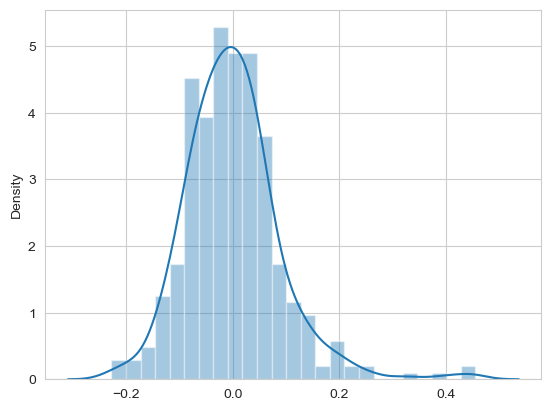

In [73]:
res = y_train - y_train_pred
sns.distplot(res)

## Step 5. Predictions and Evaluation on Test Set

In [74]:
# df_test[num_vars] = scaler.fit_transform(df_test[num_vars]) Incorrect
# from sklearn
# fit() -> on the training dataset, never on test
# transform() -> transform on the training
# fit_transform()

In [75]:
df_test[num_vars] = scaler.transform(df_test[num_vars])

In [76]:
df_test.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,furnished
265,0.229697,0.091869,0.4,0.0,0.333333,1,0,0,0,0,0.000000,1,0,0
54,0.484848,0.366420,0.4,0.5,0.333333,1,1,0,0,1,0.333333,0,0,0
171,0.303030,0.742080,0.4,0.0,0.000000,1,0,0,0,0,0.333333,1,0,0
244,0.242424,0.306582,0.4,0.0,0.333333,1,1,1,0,0,0.000000,1,0,0
268,0.227879,0.274023,0.6,0.0,0.333333,1,0,0,0,1,0.000000,0,0,0


In [77]:
df_test.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,furnished
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,0.263176,0.298548,0.408537,0.158537,0.268293,0.865854,0.195122,0.347561,0.030488,0.353659,0.205285,0.237805,0.329268,0.250000
std,0.172077,0.211922,0.147537,0.281081,0.276007,0.341853,0.397508,0.477654,0.172452,0.479569,0.289322,0.427043,0.471387,0.434339
min,0.006061,-0.016367,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142424,0.148011,0.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.226061,0.259724,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.346970,0.397439,0.400000,0.500000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,1.000000,0.250000
max,0.909091,1.263992,0.800000,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [78]:
X_test, y_test = df_test, df_test.pop("price")

In [79]:
X_test_sm = sm.add_constant(X_test)
X_test_sm.head()

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,furnished
265,1.0,0.091869,0.4,0.0,0.333333,1,0,0,0,0,0.000000,1,0,0
54,1.0,0.366420,0.4,0.5,0.333333,1,1,0,0,1,0.333333,0,0,0
171,1.0,0.742080,0.4,0.0,0.000000,1,0,0,0,0,0.333333,1,0,0
244,1.0,0.306582,0.4,0.0,0.333333,1,1,1,0,0,0.000000,1,0,0
268,1.0,0.274023,0.6,0.0,0.333333,1,0,0,0,1,0.000000,0,0,0


In [80]:
X_test_sm = X_test_sm.drop(["bedrooms", "furnished"], axis=1)

In [81]:
y_test_pred = lr_model.predict(X_test_sm)

In [82]:
y_test_pred.describe()

count    164.000000
mean       0.267596
std        0.139383
min        0.025590
25%        0.146326
50%        0.256349
75%        0.368636
max        0.773556
dtype: float64

In [83]:
# evaluate
r2_score(y_true=y_test, y_pred=y_test_pred)

0.6713505684480789

### Final Equation, if considered removing furnished first
𝑝𝑟𝑖𝑐𝑒=0.236×𝑎𝑟𝑒𝑎+0.202×𝑏𝑎𝑡ℎ𝑟𝑜𝑜𝑚𝑠+0.11×𝑠𝑡𝑜𝑟𝑖𝑒𝑠+0.05×𝑚𝑎𝑖𝑛𝑟𝑜𝑎𝑑+0.04×𝑔𝑢𝑒𝑠𝑡𝑟𝑜𝑜𝑚+0.0876×ℎ𝑜𝑡𝑤𝑎𝑡𝑒𝑟ℎ𝑒𝑎𝑡𝑖𝑛𝑔+0.0682×𝑎𝑖𝑟𝑐𝑜𝑛𝑑𝑖𝑡𝑖𝑜𝑛𝑖𝑛𝑔+0.0629×𝑝𝑎𝑟𝑘𝑖𝑛𝑔+0.0637×𝑝𝑟𝑒𝑓𝑎𝑟𝑒𝑎−0.0337×𝑢𝑛𝑓𝑢𝑟𝑛𝑖𝑠ℎ𝑒𝑑+0.0428

In [84]:
with open("housing_summary.txt", "w") as f:
    f.write(str(lr_model.summary()))

## Conclusion 1 using domain knowledge

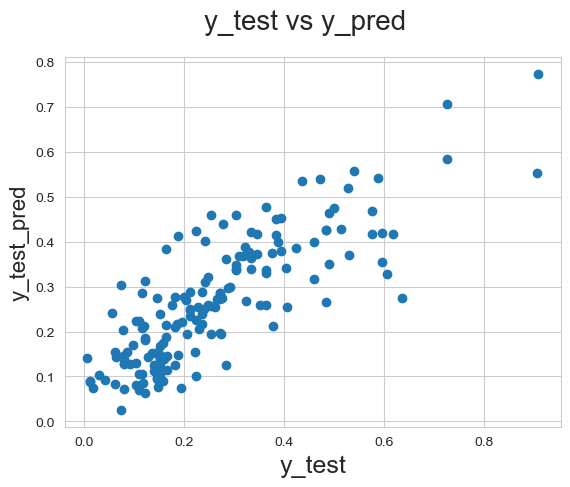

In [85]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test, y_test_pred)
fig.suptitle("y_test vs y_pred", fontsize=20)  # Plot heading
plt.xlabel("y_test", fontsize=18)  # X-label
plt.ylabel("y_test_pred", fontsize=16)  # Y-label
plt.show()

/var/folders/sn/kqm8k02j2cx8v7fm_56dlzd80000gn/T/ipykernel_1684/1957189097.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res_test)


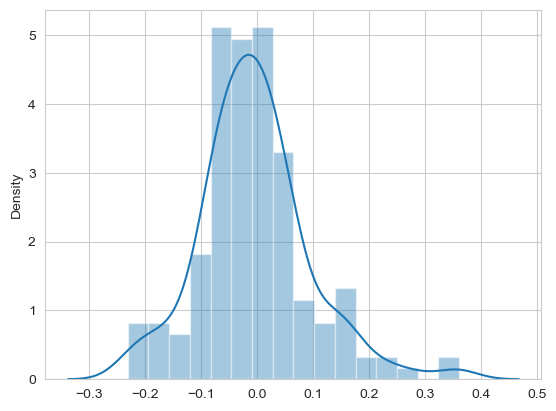

In [86]:
res_test = y_test - y_test_pred
sns.distplot(res_test)
plt.show()

## Step 6. Using Sklearn , Recursive Feature Elimination(RFE)


In [87]:
housing1 = pd.read_csv("Housing.csv")

In [88]:
housing1.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [89]:
housing1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [90]:
var_list = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea",
]
housing1[var_list] = housing1[var_list].map(lambda x: 1 if x == "yes" else 0)

In [91]:
housing1

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,0,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,0,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,0,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,0,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,0,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,0,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


### Furnishing status hyperparameter

In [92]:
status = pd.get_dummies(housing1["furnishingstatus"], dtype=int, drop_first=True)

In [93]:
status

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
540,0,1
541,1,0
542,0,1
543,0,0


In [94]:
df = pd.concat([housing1, status], axis=1)

In [95]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,0,1,furnished,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,0,0,furnished,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,0,1,semi-furnished,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,0,1,furnished,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,0,0,furnished,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,0,0,unfurnished,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished,0,0


In [96]:
df.drop("furnishingstatus", axis=1, inplace=True)

In [97]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,0,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,0,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,0,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,0,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


## Step 7. Test Train Split

In [98]:
df_train, df_test = train_test_split(df, train_size=0.7, test_size=0.3, random_state=0)

In [99]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
454,3143000,4500,3,1,2,1,0,0,0,1,0,0,0,1
392,3500000,3990,3,1,2,1,0,0,0,0,0,0,1,0
231,4690000,4320,3,1,1,1,0,0,0,0,0,1,1,0
271,4340000,1905,5,1,2,0,0,1,0,0,0,0,1,0
250,4515000,3510,3,1,3,1,0,0,0,0,0,0,1,0


### ReScaling using Min-Max Scaler

In [100]:
scaler = MinMaxScaler()

In [101]:
num_vars = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
454,0.120606,0.193548,0.5,0.0,0.333333,1,0,0,0,1,0.0,0,0,1
392,0.151515,0.156495,0.5,0.0,0.333333,1,0,0,0,0,0.0,0,1,0
231,0.254545,0.180471,0.5,0.0,0.000000,1,0,0,0,0,0.0,1,1,0
271,0.224242,0.005013,1.0,0.0,0.333333,0,0,1,0,0,0.0,0,1,0
250,0.239394,0.121622,0.5,0.0,0.666667,1,0,0,0,0,0.0,0,1,0


In [102]:
X_train, y_train = df_train, df_train.pop("price")

## Step 8. Building our model
**Using sklearn Linear Regression**

### RFE

In [103]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [104]:
rfe = RFE(lm, n_features_to_select=10)  # 10 number of variables we want ultimately
rfe = rfe.fit(X_train, y_train)

In [105]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('area', np.True_, np.int64(1)),
 ('bedrooms', np.True_, np.int64(1)),
 ('bathrooms', np.True_, np.int64(1)),
 ('stories', np.True_, np.int64(1)),
 ('mainroad', np.True_, np.int64(1)),
 ('guestroom', np.False_, np.int64(2)),
 ('basement', np.True_, np.int64(1)),
 ('hotwaterheating', np.True_, np.int64(1)),
 ('airconditioning', np.True_, np.int64(1)),
 ('parking', np.False_, np.int64(4)),
 ('prefarea', np.True_, np.int64(1)),
 ('semi-furnished', np.False_, np.int64(3)),
 ('unfurnished', np.True_, np.int64(1))]

In [106]:
len(list(zip(X_train.columns, rfe.support_, rfe.ranking_)))

13

In [107]:
col = X_train.columns[rfe.support_]
col

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'basement',
       'hotwaterheating', 'airconditioning', 'prefarea', 'unfurnished'],
      dtype='object')

In [108]:
X_train.columns[~rfe.support_]

Index(['guestroom', 'parking', 'semi-furnished'], dtype='object')

## Building stats model using above variables

In [109]:
X_train_rfe = X_train[col]

In [110]:
X_train_rfe.head()

,area,bedrooms,bathrooms,stories,mainroad,basement,hotwaterheating,airconditioning,prefarea,unfurnished
454,0.193548,0.5,0.0,0.333333,1,0,0,1,0,1
392,0.156495,0.5,0.0,0.333333,1,0,0,0,0,0
231,0.180471,0.5,0.0,0.000000,1,0,0,0,1,0
271,0.005013,1.0,0.0,0.333333,0,1,0,0,0,0
250,0.121622,0.5,0.0,0.666667,1,0,0,0,0,0


In [111]:
# Adding constant
X_train_rfe = sm.add_constant(X_train_rfe)

In [112]:
lm = sm.OLS(y_train, X_train_rfe)

In [113]:
rfe_model = lm.fit()

In [114]:
print(rfe_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     67.59
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           2.94e-77
Time:                        05:36:31   Log-Likelihood:                 350.76
No. Observations:                 381   AIC:                            -679.5
Df Residuals:                     370   BIC:                            -636.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0146      0.022     

In [115]:
with open("RFE_Housing.txt", "w") as f:
    f.write(str(rfe_model.summary()))

In [116]:
X_train_new = X_train_rfe.drop("bedrooms", axis=1)

In [117]:
X_train_lm = sm.add_constant(X_train_new)
lm = sm.OLS(y_train, X_train_lm)

In [118]:
rfe_model_new = lm.fit()

In [119]:
print(rfe_model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     74.63
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           9.55e-78
Time:                        05:36:32   Log-Likelihood:                 349.65
No. Observations:                 381   AIC:                            -679.3
Df Residuals:                     371   BIC:                            -639.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0350      0.017     

In [120]:
vif = pd.DataFrame()
t = X_train_new
vif["Features"] = t.columns
vif["VIF"] = [variance_inflation_factor(t.values, i) for i in range(t.shape[1])]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
0,const,11.14
3,stories,1.27
1,area,1.25
2,bathrooms,1.21
7,airconditioning,1.19
8,prefarea,1.19
5,basement,1.16
4,mainroad,1.13
9,unfurnished,1.07
6,hotwaterheating,1.05


In [121]:
X_train_new = X_train_new.drop("const", axis=1)

### Final Model

In [122]:
len(X_train_new.columns)

9

In [123]:
X_train_lm = sm.add_constant(X_train_new)
lm = sm.OLS(y_train, X_train_lm)

In [124]:
rfe_model_new = lm.fit()
print(rfe_model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     74.63
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           9.55e-78
Time:                        05:36:32   Log-Likelihood:                 349.65
No. Observations:                 381   AIC:                            -679.3
Df Residuals:                     371   BIC:                            -639.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0350      0.017     

In [125]:
len(X_train_new.columns)

9

In [126]:
# X_train_new = X_train_new.drop('unfurnished',axis=1)
# X_train_lm = sm.add_constant(X_train_new)
# lm = sm.OLS(y_train,X_train_lm)
# rfe_model_new = lm.fit()
# print(rfe_model_new.summary())

### Calculating Variance Inflation Factor

In [127]:
vif = pd.DataFrame()
t = X_train_new
vif["Features"] = t.columns
vif["VIF"] = [variance_inflation_factor(t.values, i) for i in range(t.shape[1])]
vif["VIF"] = round(vif["VIF"], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
3,mainroad,4.86
0,area,4.15
2,stories,2.30
6,airconditioning,1.77
4,basement,1.64
1,bathrooms,1.61
7,prefarea,1.55
8,unfurnished,1.35
5,hotwaterheating,1.09


In [128]:
y_train_price = rfe_model_new.predict(X_train_lm)

In [129]:
y_train_price

454    0.228334
392    0.173717
231    0.203489
271    0.119185
250    0.200741
         ...   
70     0.452726
277    0.351823
9      0.488742
359    0.084408
192    0.303150
Length: 381, dtype: float64

/var/folders/sn/kqm8k02j2cx8v7fm_56dlzd80000gn/T/ipykernel_1684/2424726034.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res, bins=20)


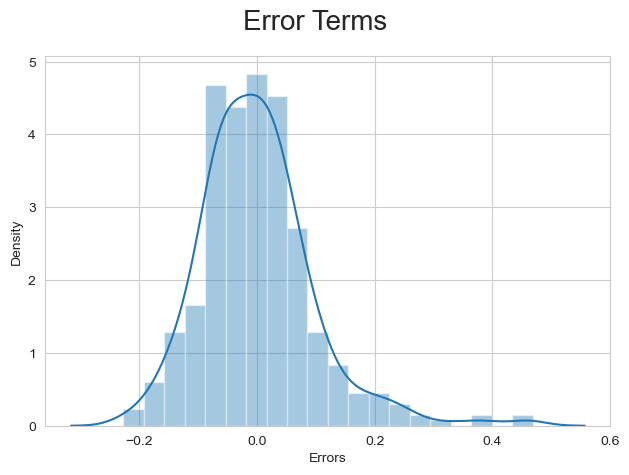

In [130]:
res = y_train - y_train_price
fig = plt.figure()

sns.distplot(res, bins=20)
fig.suptitle("Error Terms", fontsize=20)
plt.xlabel("Errors", fontsize=10)
plt.tight_layout()
plt.show()

In [131]:
df_test[num_vars] = scaler.transform(df_test[num_vars])
# num_vars

In [132]:
x_test, y_test = df_test, df_test.pop("price")

In [133]:
X_test = df_test

In [134]:
# Testing on test set

X_test_new = X_test[X_train_new.columns]

# Adding constant
X_test_new = sm.add_constant(X_test_new)

In [135]:
len(X_test_new.columns)

10

In [136]:
# Making predictions
y_pred = rfe_model_new.predict(X_test_new)

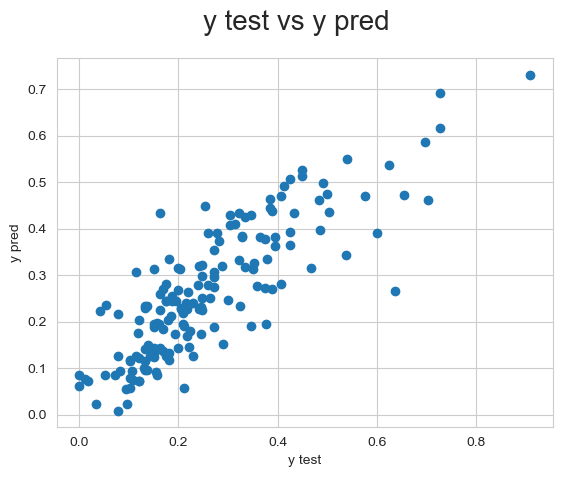

In [137]:
res = y_test - y_pred
fig = plt.figure()

plt.scatter(y_test, y_pred)
fig.suptitle("y test vs y pred", fontsize=20)
plt.xlabel("y test", fontsize=10)
plt.ylabel("y pred", fontsize=10)


plt.show()

# Final Conclusion: Using both automated approach and domain knowledge we were able to arrive at similar outcomes as shown in the plots above

In [138]:
def stepwise_selection(X, y, direction="forward", max_features=None):
    """
    Performs stepwise feature selection using AIC.

    Args:
        X (pd.DataFrame): The input features.
        y (pd.Series): The target variable.
        direction (str, optional): 'forward' or 'backward'. Defaults to 'forward'.
        max_features (int, optional): Maximum number of features to select.
                                     Defaults to None.

    Returns:
        list: The selected feature names.
    """
    if direction == "forward":
        sfs = SFS(
            LinearRegression(),
            k_features=max_features,
            forward=True,
            floating=False,
            scoring="neg_mean_squared_error",
            cv=0,
        )
    elif direction == "backward":
        sfs = SFS(
            LinearRegression(),
            k_features=10,
            forward=False,
            floating=False,
            scoring="neg_mean_squared_error",
            cv=0,
        )
    else:
        raise ValueError("direction must be 'forward' or 'backward'")

    sfs.fit(X, y)
    # print(r2_score(sfs,y_train))
    # print(dir(sfs))
    return sfs

In [139]:
lm1 = stepwise_selection(X_train, y_train, direction="backward")

In [140]:
dir(lm1)

['_TESTING_INTERRUPT_MODE',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_calc_confidence',
 '_check_feature_names',
 '_check_fitted',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_feature_selector',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params',
 '_get_tags',
 '_more_tags',
 '_replace_estimator',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_set_params',
 '_validate_da

In [141]:
lm1.scoring

'neg_mean_squared_error'

In [142]:
lm1.k_feature_names_

('area',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'unfurnished')

In [143]:
backward = lm1.fit(X_test, y_test)

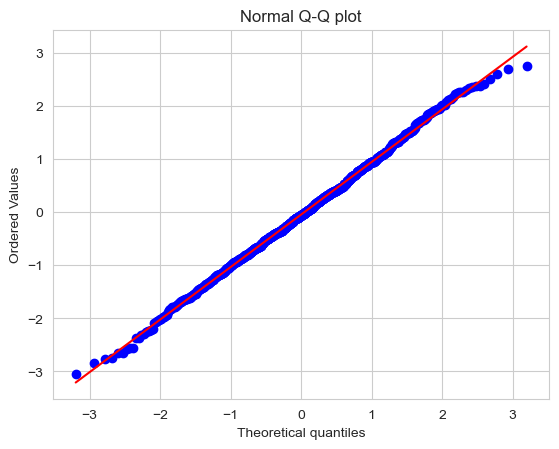

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate example data
np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=1000)

# Create Q-Q plot
stats.probplot(data, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered Values")
plt.grid(True)
plt.show()

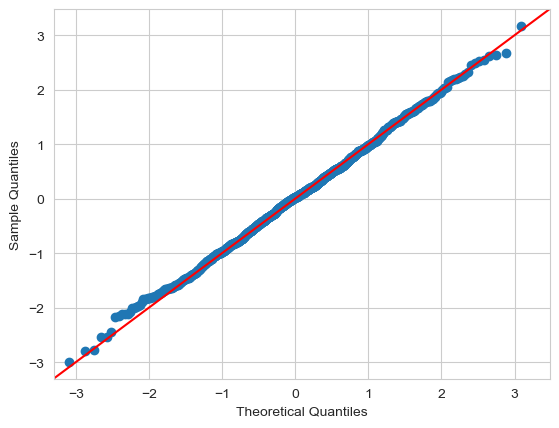

In [145]:
data = np.random.normal(0, 1, 1000)

# Create a Q-Q plot against the standard normal distribution
fig = sm.qqplot(data, line="45")
plt.show()

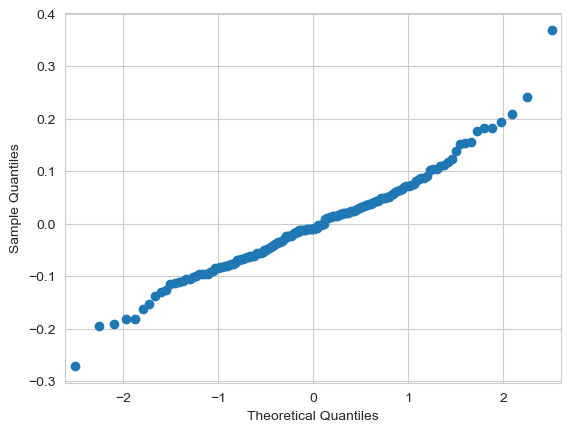

In [146]:
sm.qqplot(res)
plt.show()

In [147]:
lm1

SequentialFeatureSelector(cv=0, estimator=LinearRegression(), forward=False,
                          k_features=(10, 10),
                          scoring='neg_mean_squared_error')